# Seaborn 可视化教程

## Seaborn 简介
- Seaborn 是基于 Matplotlib 的高级可视化库
- 与 Pandas 无缝集成
- 内置多种统计图表和美观的主题

## 安装与导入

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 设置 Seaborn 样式
sns.set_theme(style='darkgrid', palette='Set2')

## 加载内置数据集

In [2]:
# Seaborn 自带的经典数据集
tips = sns.load_dataset('tips')      # 餐厅小费数据
iris = sns.load_dataset('iris')      # 鸢尾花数据
titanic = sns.load_dataset('titanic') # 泰坦尼克数据

print(tips.head())
print(iris.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


## 样式和主题

### 不同主题

IndexError: index 3 is out of bounds for axis 1 with size 3

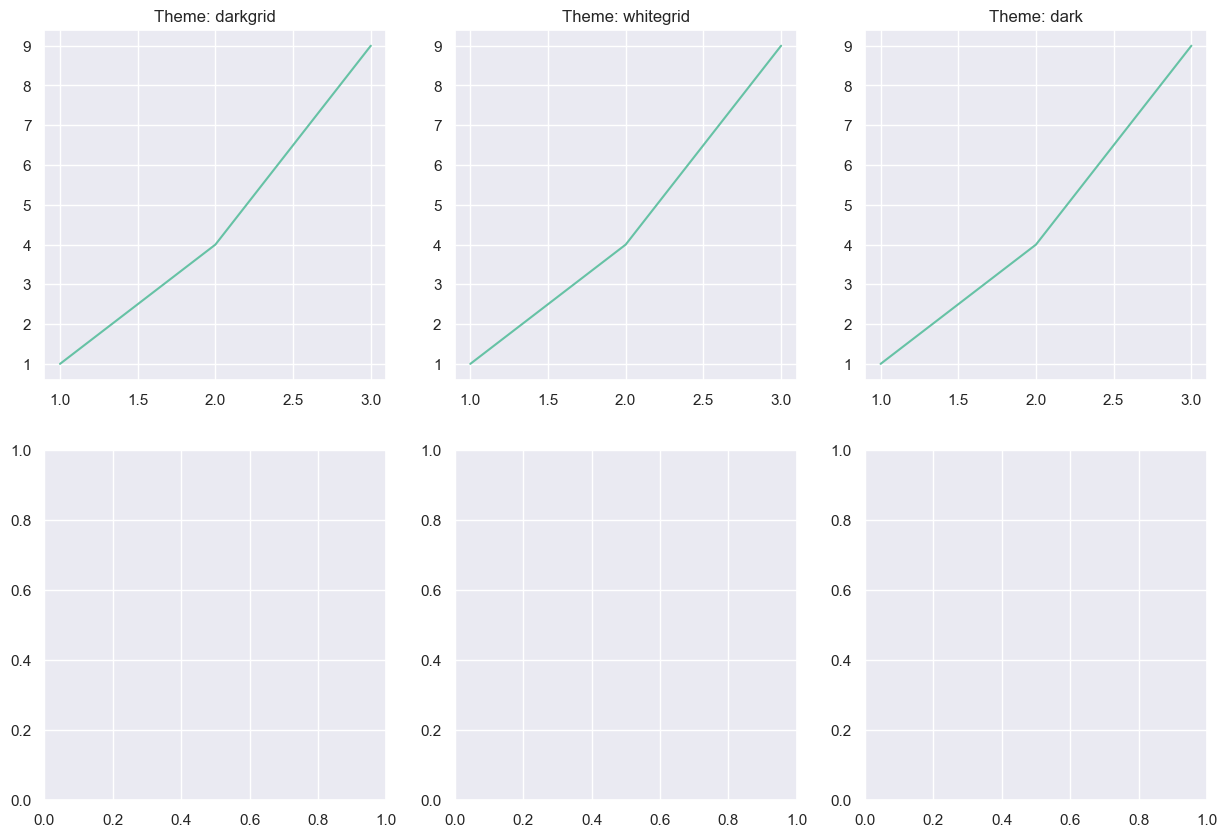

In [3]:
# 五种主题：darkgrid, whitegrid, dark, white, ticks
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

themes = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
for i, theme in enumerate(themes):
    sns.set_theme(style=theme)
    axes[0, i].plot([1,2,3], [1,4,9])
    axes[0, i].set_title(f'Theme: {theme}')

plt.tight_layout()

### 调色板

In [4]:
# 查看可用调色板
sns.color_palette('husl', 8)
sns.color_palette('Set2', 8)
sns.color_palette('coolwarm', 8)

[(0.3634607953411765, 0.4847836818509804, 0.9010188868941177),
 (0.5108243242509803, 0.6493966148235294, 0.9850787763764707),
 (0.6672529243333334, 0.7791764569999999, 0.992959213),
 (0.8049647588235295, 0.8516661605568627, 0.9261650744313725),
 (0.9193759889058823, 0.8312727235294118, 0.7828736304470588),
 (0.968203399, 0.7208441, 0.6122929913333334),
 (0.9440545734235294, 0.5531534787490197, 0.4355484903137255),
 (0.8523781350078431, 0.34649194649411763, 0.2803464686980392)]

## 分布可视化

### 直方图和核密度估计

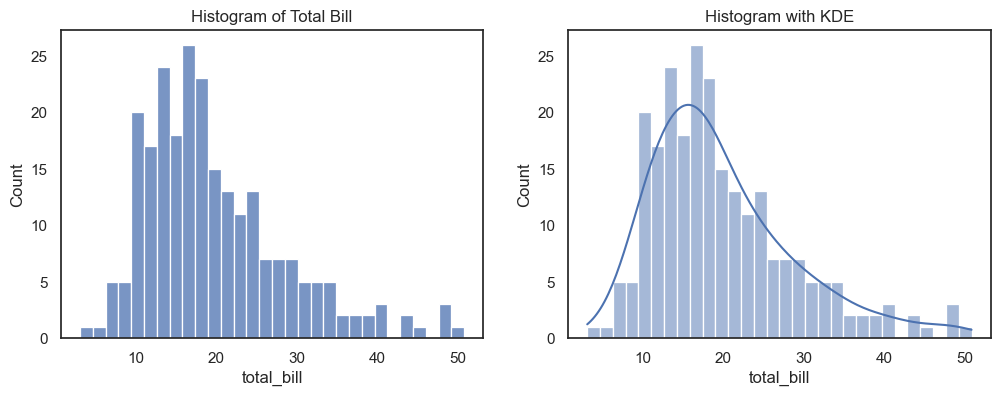

In [5]:
# 单变量直方图 + KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 直方图
sns.histplot(data=tips, x='total_bill', bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histogram of Total Bill')

# 直方图 + KDE（更平滑）
sns.histplot(data=tips, x='total_bill', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Histogram with KDE')

plt.show()

### 核密度图

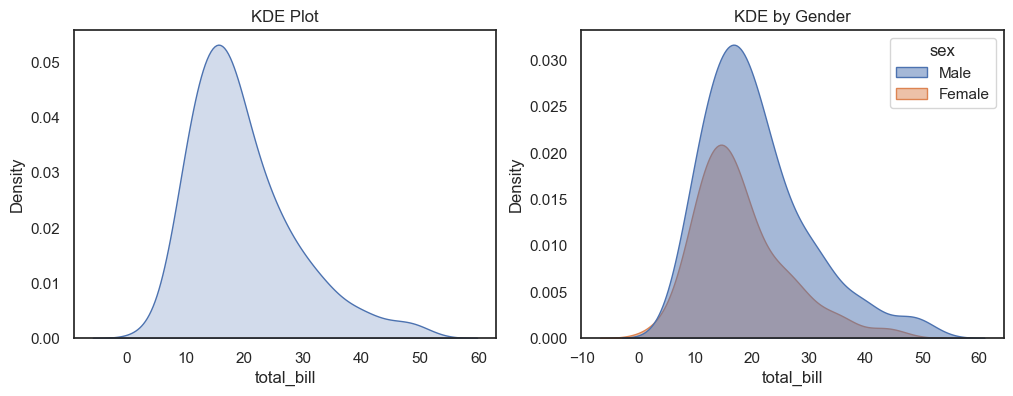

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 单变量 KDE
sns.kdeplot(data=tips, x='total_bill', fill=True, ax=axes[0])
axes[0].set_title('KDE Plot')

# 分组 KDE（按性别）
sns.kdeplot(data=tips, x='total_bill', hue='sex', fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('KDE by Gender')

plt.show()

### 箱线图

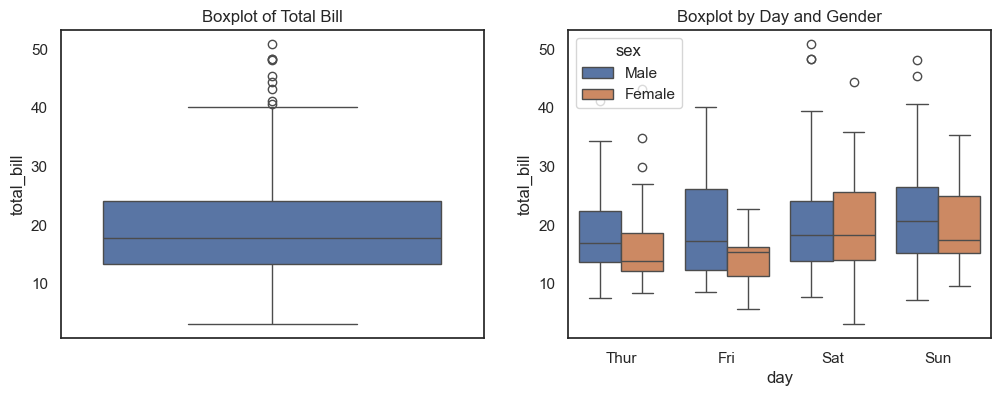

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 单变量箱线图
sns.boxplot(data=tips, y='total_bill', ax=axes[0])
axes[0].set_title('Boxplot of Total Bill')

# 分组箱线图
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1])
axes[1].set_title('Boxplot by Day and Gender')

plt.show()

### 小提琴图

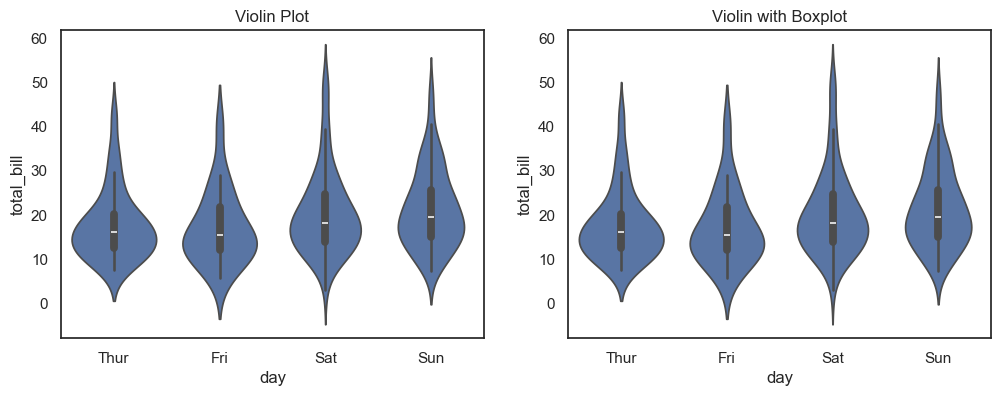

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 小提琴图
sns.violinplot(data=tips, x='day', y='total_bill', ax=axes[0])
axes[0].set_title('Violin Plot')

# 小提琴图 + 箱线图叠加
sns.violinplot(data=tips, x='day', y='total_bill', inner='box', ax=axes[1])
axes[1].set_title('Violin with Boxplot')

plt.show()

## 分类数据可视化

### 分类散点图

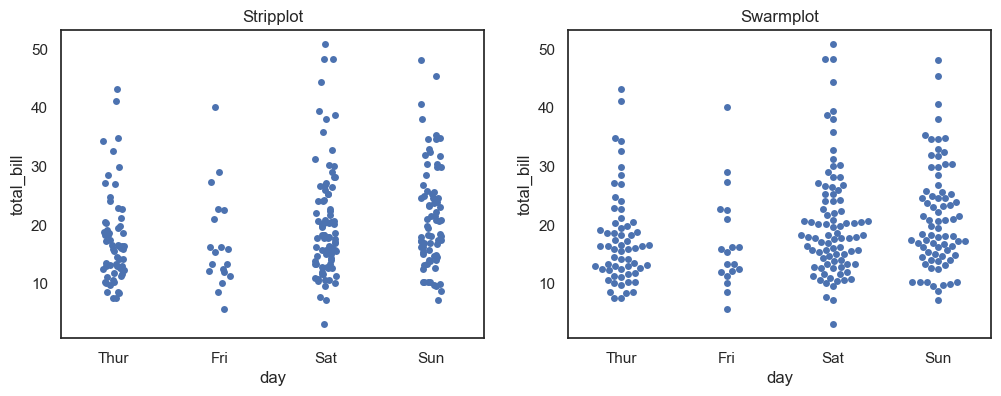

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# stripplot（点会重叠）
sns.stripplot(data=tips, x='day', y='total_bill', jitter=True, ax=axes[0])
axes[0].set_title('Stripplot')

# swarmplot（点不重叠，更美观但慢）
sns.swarmplot(data=tips, x='day', y='total_bill', ax=axes[1])
axes[1].set_title('Swarmplot')

plt.show()

### 分类条形图

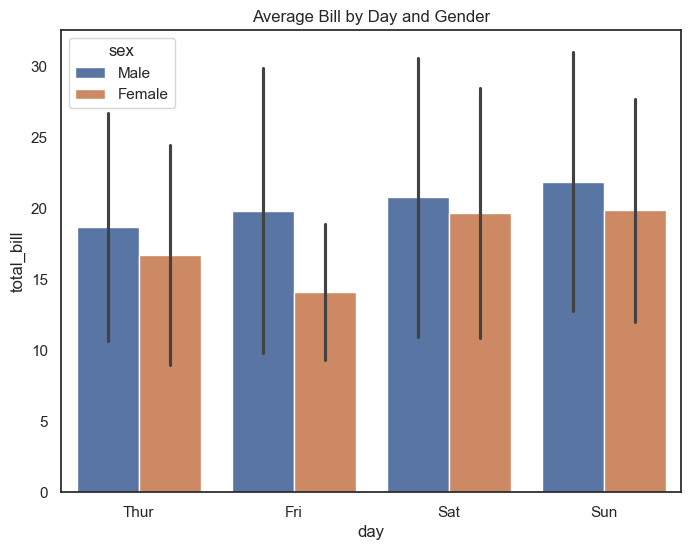

In [11]:
# 分组条形图
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=tips, x='day', y='total_bill', hue='sex', errorbar='sd', ax=ax)
ax.set_title('Average Bill by Day and Gender')
plt.show()

### 分类计数图

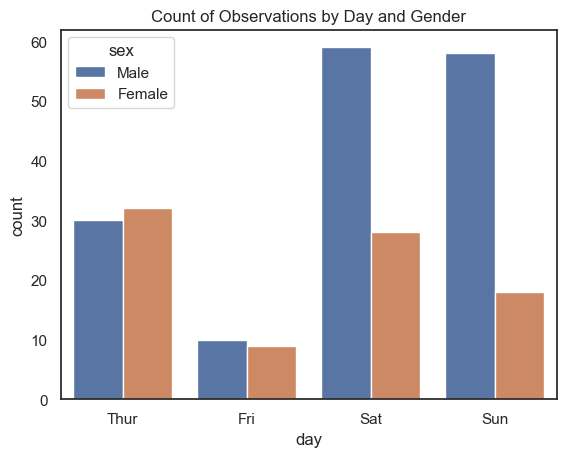

In [12]:
fig, ax = plt.subplots()
sns.countplot(data=tips, x='day', hue='sex', ax=ax)
ax.set_title('Count of Observations by Day and Gender')
plt.show()

## 关系可视化

### 散点图+回归线

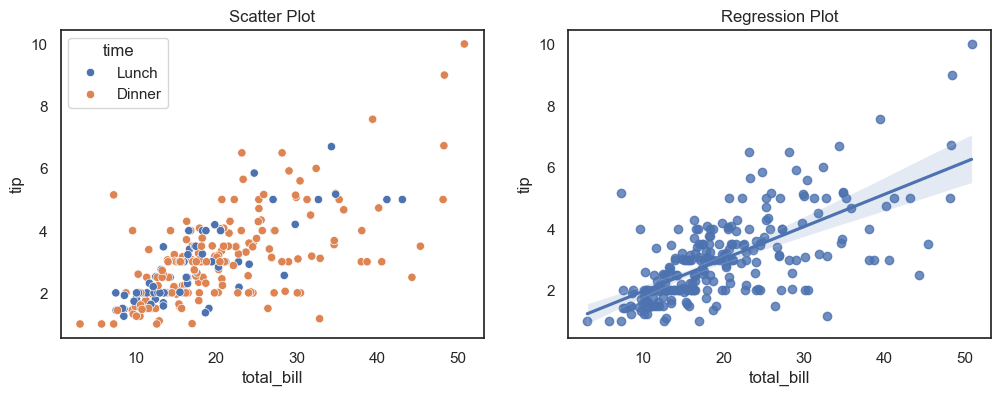

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 简单散点图
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', ax=axes[0])
axes[0].set_title('Scatter Plot')

# 散点图 + 回归线
sns.regplot(data=tips, x='total_bill', y='tip', ax=axes[1])
axes[1].set_title('Regression Plot')

plt.show()

### 关系矩阵

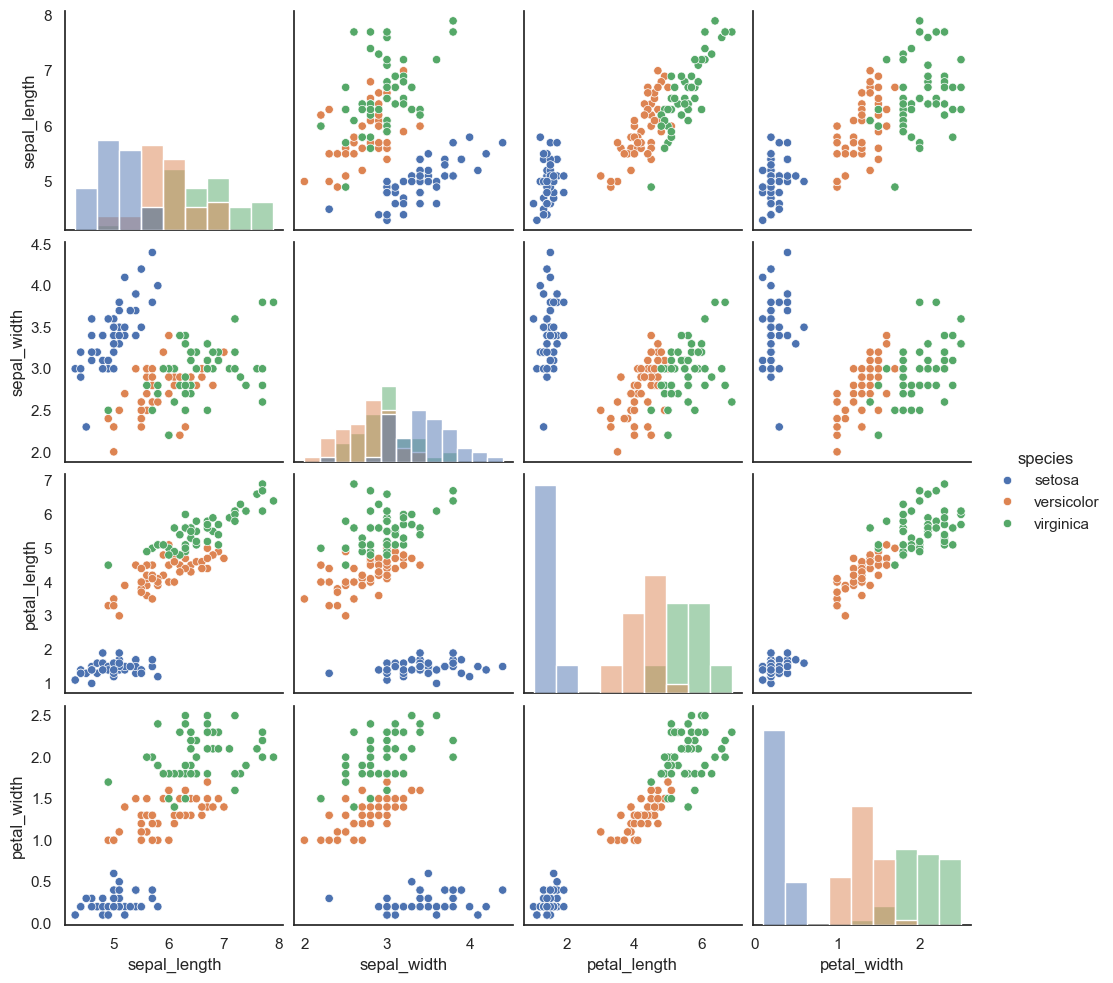

In [14]:
# 多变量关系矩阵（数据量大时较慢）
sns.pairplot(data=iris, hue='species', diag_kind='hist')
plt.show()

### 热力图

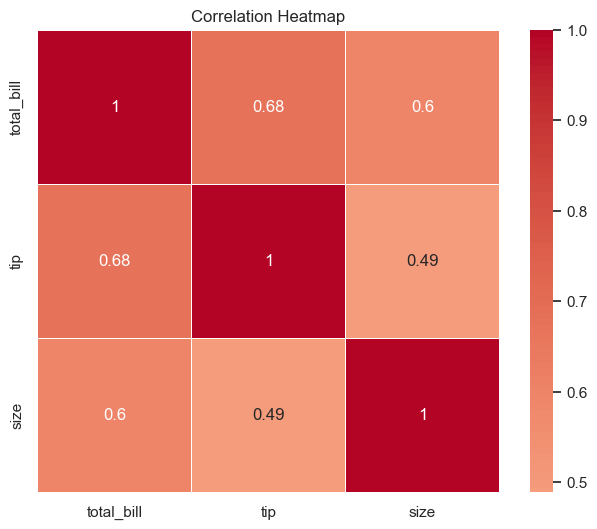

In [15]:
# 计算相关性矩阵
corr = tips.select_dtypes(include=[np.number]).corr()

# 绘制热力图
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()

## 多子图

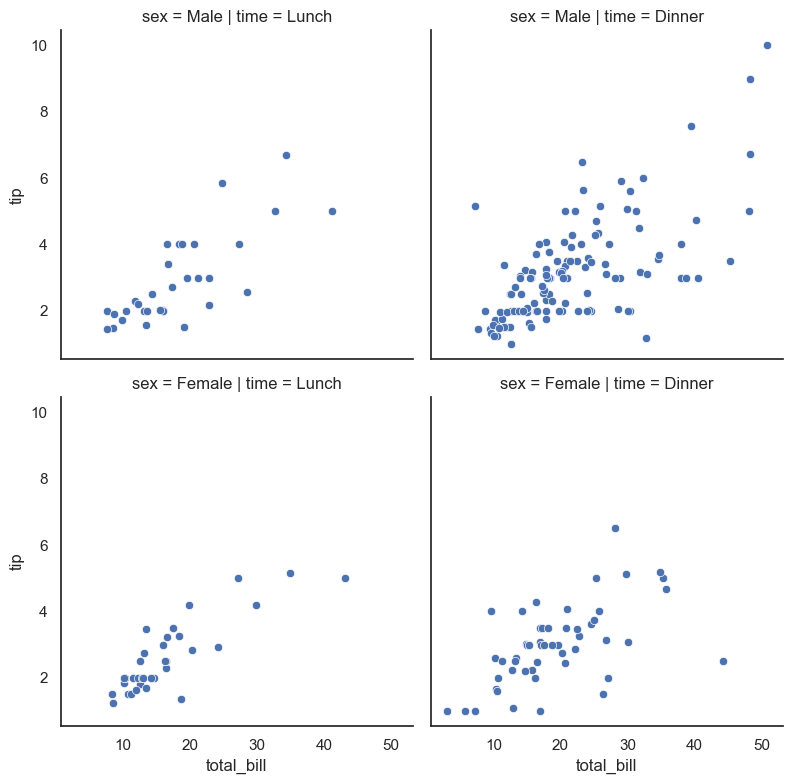

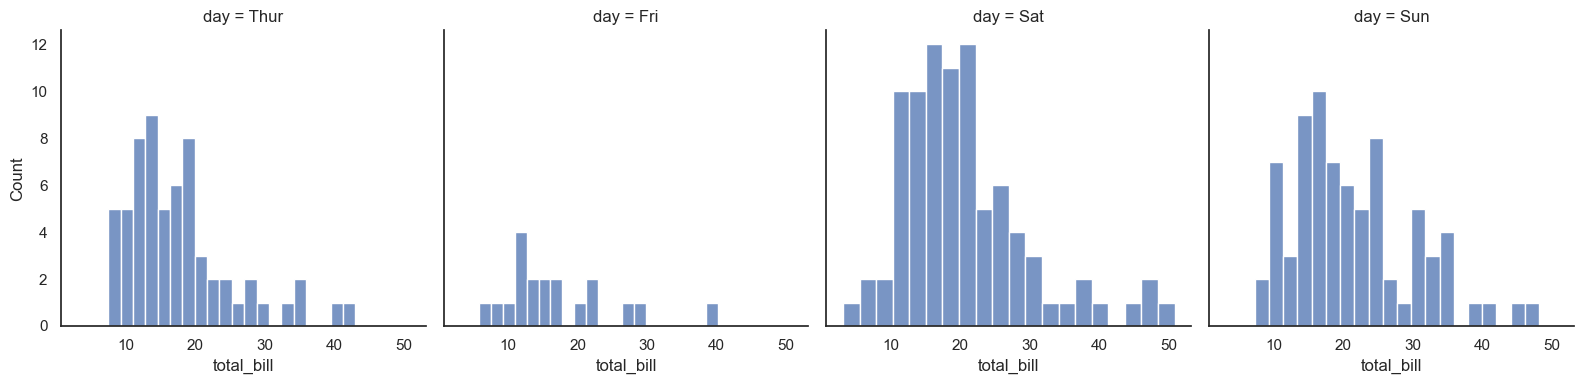

In [16]:
# 按列分面
g = sns.FacetGrid(tips, col='time', row='sex', height=4)
g.map(sns.scatterplot, 'total_bill', 'tip')
g.add_legend()
plt.show()

# 按行分面
g = sns.FacetGrid(tips, col='day', height=4)
g.map(sns.histplot, 'total_bill', bins=20)
plt.show()

## 综合案例：Titanic 数据完整分析

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


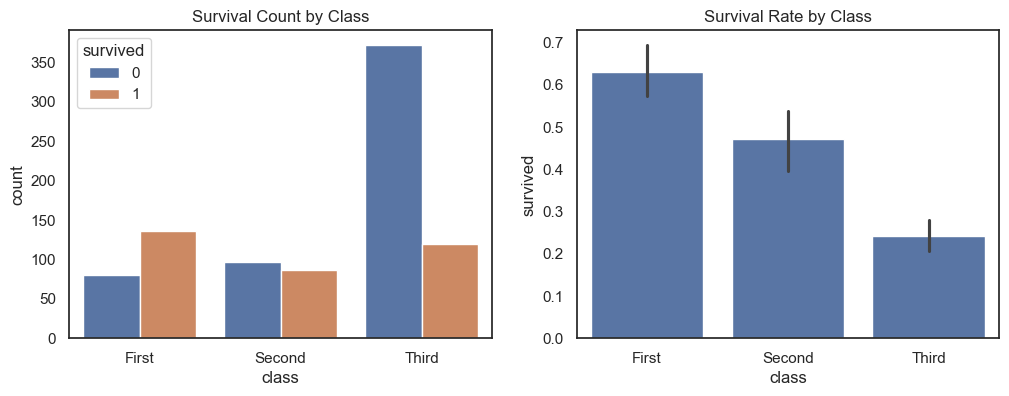

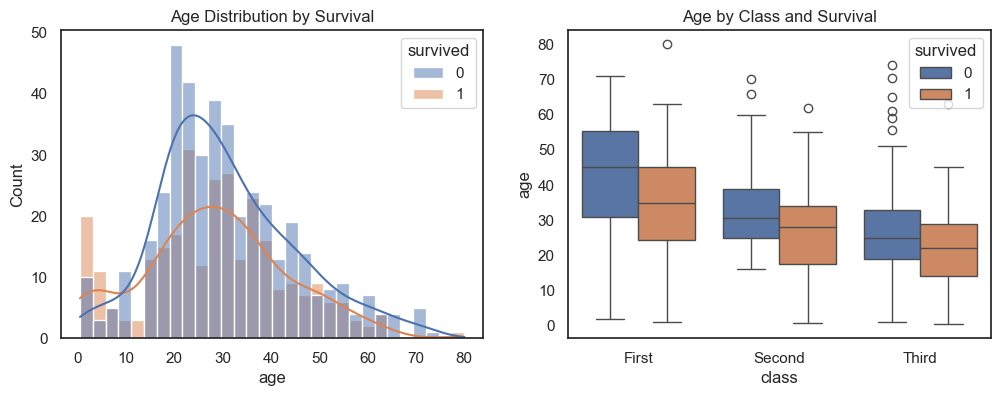

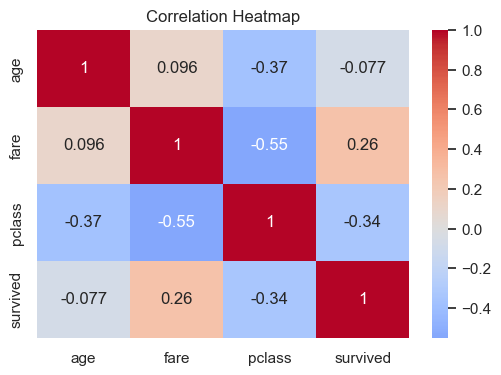

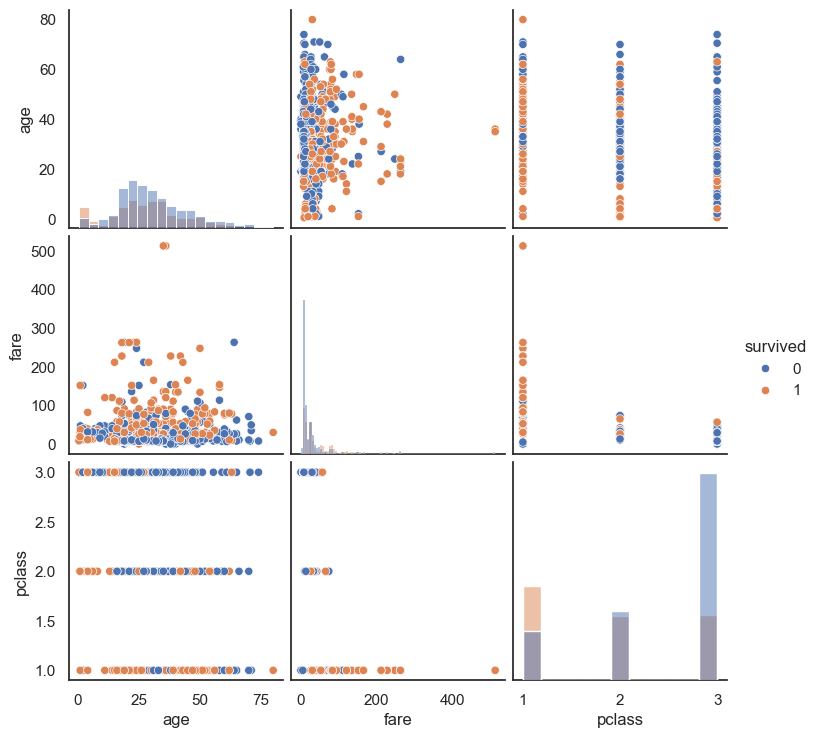

In [17]:
# 加载数据
titanic = sns.load_dataset('titanic')
print(titanic.head())

# 1. 生存率与舱位等级的关系
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 分组计数图
sns.countplot(data=titanic, x='class', hue='survived', ax=axes[0])
axes[0].set_title('Survival Count by Class')

# 分组条形图（百分比）
sns.barplot(data=titanic, x='class', y='survived', ax=axes[1])
axes[1].set_title('Survival Rate by Class')

plt.show()

# 2. 年龄与生存率的关系
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 年龄分布（按是否生存）
sns.histplot(data=titanic, x='age', hue='survived', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution by Survival')

# 年龄箱线图（按舱位和生存状态）
sns.boxplot(data=titanic, x='class', y='age', hue='survived', ax=axes[1])
axes[1].set_title('Age by Class and Survival')

plt.show()

# 3. 相关性热力图
numeric_cols = ['age', 'fare', 'pclass', 'survived']
corr = titanic[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()

# 4. 综合关系图
sns.pairplot(data=titanic[['age', 'fare', 'pclass', 'survived']].dropna(), 
             hue='survived', diag_kind='hist')
plt.show()